                                       DECISION TREE

Tasks:

1. Data Preparation:

Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).


In [44]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report

In [45]:
df = pd.read_csv('heart-diseases.csv')
df

,age,gender,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,55,1,3,145,233,1,0,150,0,2.3,1,2,1
1,43,0,2,130,250,0,1,187,0,3.5,2,3,0
2,66,1,1,120,200,0,0,172,0,1.5,1,1,0
3,51,1,3,140,240,1,1,160,1,0.8,2,3,1
4,52,0,2,125,220,0,0,180,0,1.2,2,2,0
5,62,1,4,150,260,1,1,155,1,2.0,1,1,1
6,72,0,1,115,190,0,0,170,0,1.0,2,3,0
7,44,1,3,135,230,1,1,165,1,0.5,1,2,1
8,32,0,2,128,210,0,0,175,0,1.8,2,3,0
9,58,1,4,148,255,1,1,158,1,2.2,1,1,1


In [46]:
df.shape

(10, 13)

In [47]:
df.head()

,age,gender,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,55,1,3,145,233,1,0,150,0,2.3,1,2,1
1,43,0,2,130,250,0,1,187,0,3.5,2,3,0
2,66,1,1,120,200,0,0,172,0,1.5,1,1,0
3,51,1,3,140,240,1,1,160,1,0.8,2,3,1
4,52,0,2,125,220,0,0,180,0,1.2,2,2,0


In [48]:
df.tail()

,age,gender,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
5,62,1,4,150,260,1,1,155,1,2.0,1,1,1
6,72,0,1,115,190,0,0,170,0,1.0,2,3,0
7,44,1,3,135,230,1,1,165,1,0.5,1,2,1
8,32,0,2,128,210,0,0,175,0,1.8,2,3,0
9,58,1,4,148,255,1,1,158,1,2.2,1,1,1


In [49]:
df.nunique()

age         10
gender       2
cp           4
trestbps    10
chol        10
fbs          2
restecg      2
thalch      10
exang        2
oldpeak     10
slope        2
thal         3
num          2
dtype: int64

In [50]:
df.isna().sum()

age         0
gender      0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

2. Exploratory Data Analysis (EDA):

Perform exploratory data analysis to understand the structure of the dataset.

Check for missing values, outliers, and inconsistencies in the data.

Visualize the distribution of features, including histograms, box plots, and correlation matrices.


In [51]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
age         0
gender      0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64


In [53]:
import matplotlib.pyplot as plt

<Figure size 1200x1000 with 0 Axes>

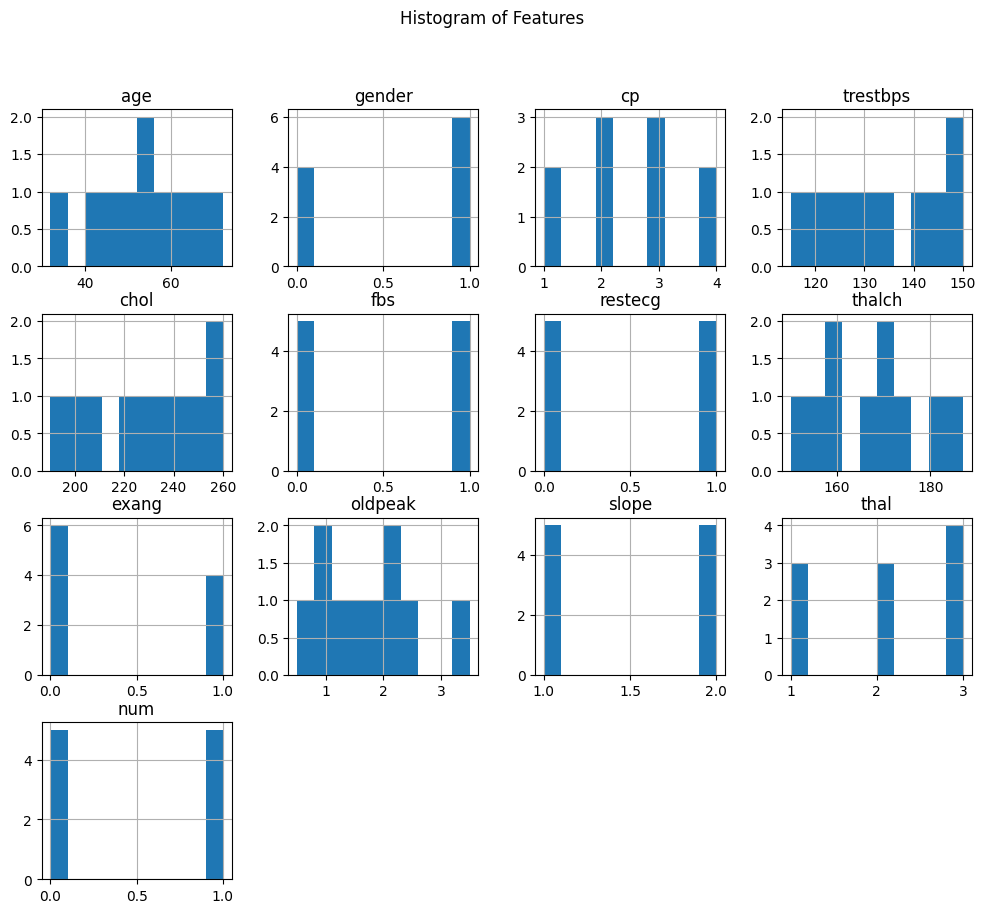

In [55]:

# Visualize distribution of features
plt.figure(figsize=(12, 10))
df.hist(figsize=(12, 10))
plt.suptitle("Histogram of Features")
plt.show()


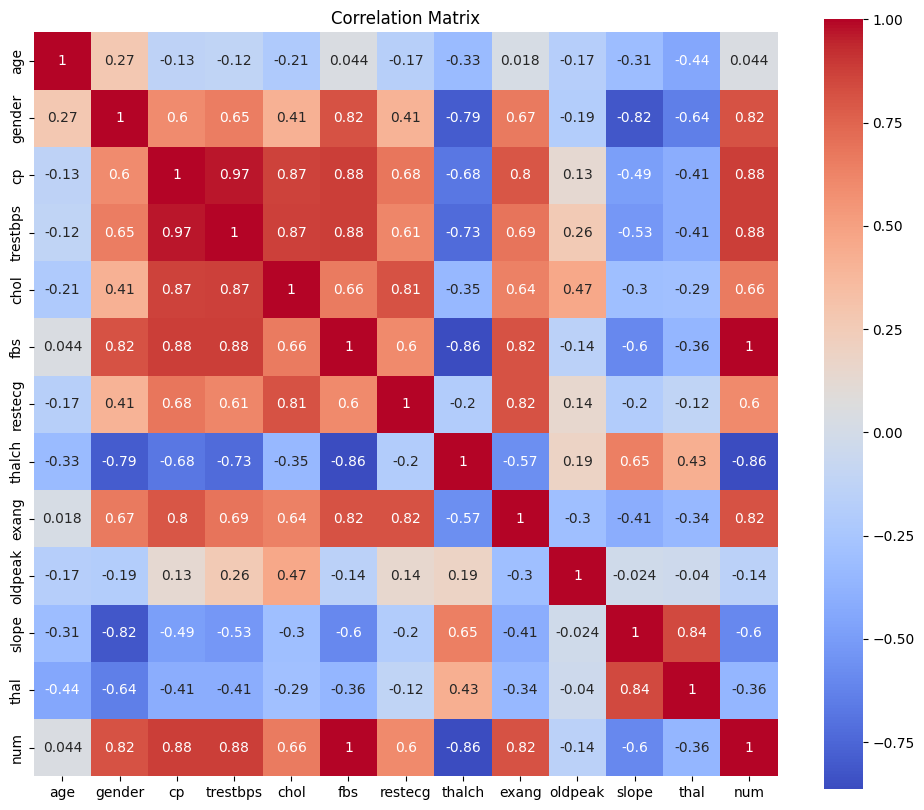

In [56]:

# Correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.show()


3. Feature Engineering:

If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.



In [61]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [62]:
# Separate features and target
X = df.drop('num', axis=1)
y = df['num']


In [68]:

# Identify categorical and numerical columns
categorical_cols = ['gender', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']


In [69]:

# Create a preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ]
)


In [70]:

# Fit and transform the data
X_preprocessed = preprocessor.fit_transform(X)


In [72]:

# Convert the preprocessed data back to a DataFrame
X_preprocessed = pd.DataFrame(X_preprocessed, columns=preprocessor.get_feature_names_out())


In [73]:

print(X_preprocessed.head())

   num__age  num__trestbps  num__chol  num__thalch  num__oldpeak  \
0  0.133393       1.000462   0.187463    -1.548607      0.742315   
1 -0.933748      -0.315935   0.946240     1.782699      2.179055   
2  1.111605      -1.193534  -1.285458     0.432169     -0.215511   
3 -0.222321       0.561663   0.499900    -0.648254     -1.053609   
4 -0.133393      -0.754734  -0.392779     1.152452     -0.574696   

   cat__gender_0  cat__gender_1  cat__cp_1  cat__cp_2  cat__cp_3  ...  \
0            0.0            1.0        0.0        0.0        1.0  ...   
1            1.0            0.0        0.0        1.0        0.0  ...   
2            0.0            1.0        1.0        0.0        0.0  ...   
3            0.0            1.0        0.0        0.0        1.0  ...   
4            1.0            0.0        0.0        1.0        0.0  ...   

   cat__fbs_1  cat__restecg_0  cat__restecg_1  cat__exang_0  cat__exang_1  \
0         1.0             1.0             0.0           1.0           0.0  

4. Decision Tree Classification:

Split the dataset into training and testing sets (e.g., using an 80-20 split).

Implement a Decision Tree Classification model using a library like scikit-learn.

Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).


In [74]:
model = DecisionTreeClassifier(criterion="gini")

In [75]:
df.columns

Index(['age', 'gender', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [76]:
from sklearn.model_selection import train_test_split

X = df.drop(["num"],axis=1)  # drop the target which means you have only features in the X variable... 
y = df["num"]  ## only select the target .. 

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,shuffle=True)



In [100]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [77]:
len(X_train),len(y_train)

(7, 7)

In [78]:
len(X_test),len(y_test)

(3, 3)

In [79]:
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [80]:
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

In [81]:
accuracy_score(y_train,pred_train)

1.0

In [82]:
accuracy_score(y_test,pred_test)

1.0

In [83]:
print(classification_report(y_train,pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         2

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



In [84]:
print(classification_report(y_test,pred_test))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [93]:
model1 = DecisionTreeClassifier(criterion="entropy")

model1.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [94]:
pred_train1 = model1.predict(X_train)
pred_test1 = model1.predict(X_test)

In [95]:
accuracy_score(y_train,pred_train1)

1.0

In [96]:
accuracy_score(y_test,pred_test1)

0.6666666666666666

In [97]:
print(classification_report(y_train,pred_train1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         2

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



5. Hyperparameter Tuning:

Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.


In [85]:
from sklearn.model_selection import GridSearchCV


In [86]:

# Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}


In [87]:

# Perform grid search
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)


c:\Users\PRINCE\python\python practise\.venv\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [88]:

# Print best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best Score: 0.8


6. Model Evaluation and Analysis:

Analyse the performance of the Decision Tree model using the evaluation metrics obtained.

Visualize the decision tree structure to understand the rules learned by the model and identify important features


[Text(0.5, 0.75, 'x[5] <= 0.5\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.625, 0.5, '  False')]

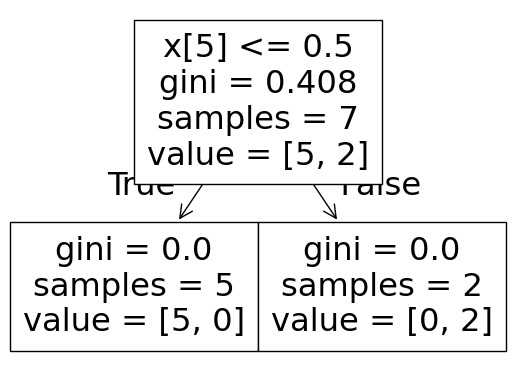

In [110]:
from sklearn import tree

tree.plot_tree(model)

[Text(0.5, 0.75, 'x[7] <= 162.5\nentropy = 0.863\nsamples = 7\nvalue = [5, 2]'),
 Text(0.25, 0.25, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'entropy = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.625, 0.5, '  False')]

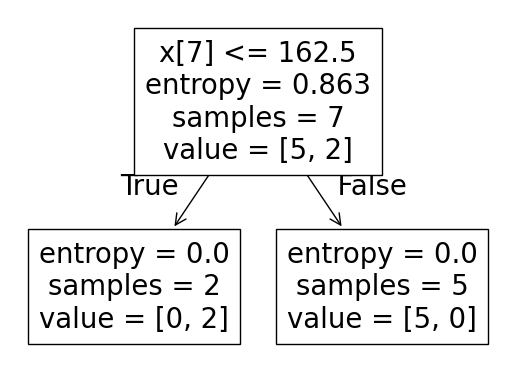

In [111]:
from sklearn import tree

tree.plot_tree(model1)

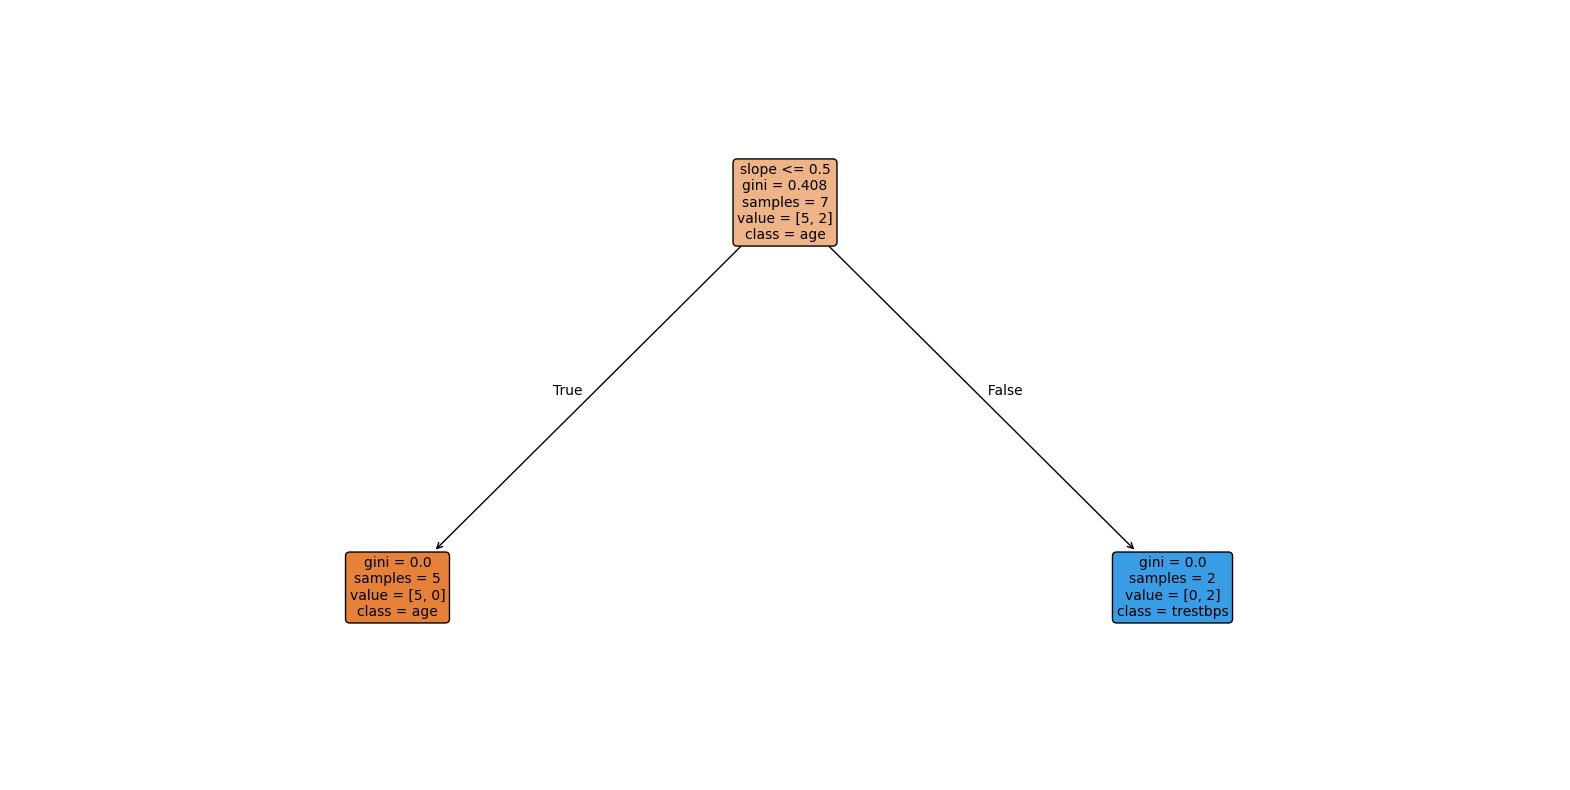

In [114]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(20,10))
tree.plot_tree(model, 
               filled=True,  # Fill nodes with colors
               feature_names=['gender', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'],
               class_names=['age', 'trestbps', 'chol', 'thalch', 'oldpeak'],
               rounded=True,  # Rounded boxes
               fontsize=10)
plt.show()

Interview Questions:

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?


Common hyperparameters include:

- max_depth: controls the maximum depth of the tree, preventing overfitting.

- min_samples_split: controls the minimum number of samples required to split an internal node, preventing overfitting.

- criterion: controls the metric used to measure the quality of a split (e.g., gini, entropy).

- min_samples_leaf: controls the minimum number of samples required to be at a leaf node, preventing overfitting.



2. What is the difference between the Label encoding and One-hot encoding?


Label encoding:

Label encoding is a technique where categorical variables are encoded as integers, preserving the ordinal relationship between categories.

label encoding is preferred when there is an ordinal relationship.

 One-hot encoding:
	
	One-hot encoding is a technique where categorical variables are encoded as binary vectors, creating a new feature for each category. 
	
	One-hot encoding is often preferred when there is no ordinal relationship between categories.